## Phase 1: Data Inspection & Structural Audit

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

In [6]:
df = pd.read_csv('F:/Bootcamp 1.0/Assignments/assignment-06/train.csv')

In [7]:
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [10]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [14]:
numerical_cols

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

In [12]:
categorical_cols 

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [15]:
numerical_cols[:10]

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1']

In [16]:
categorical_cols[:10] 

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1']

In [17]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [18]:
df["SalePrice"].skew()

1.8828757597682129

In [19]:
df["SalePrice"].kurtosis()

6.536281860064529

<Axes: xlabel='SalePrice', ylabel='Count'>

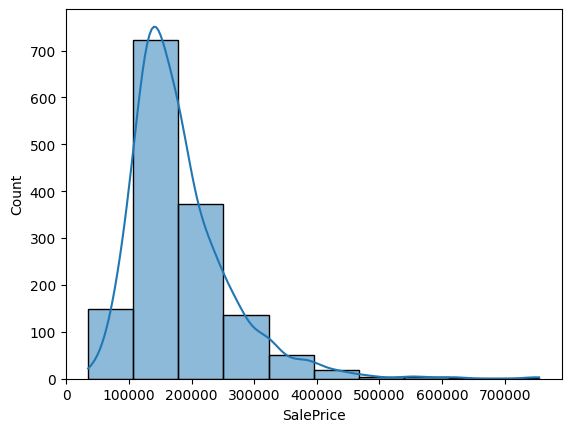

In [22]:
sns.histplot(df["SalePrice"], bins=10 , kde=True)

In [24]:
df["SalePrice_log"] = np.log1p(df["SalePrice"])   

<Axes: xlabel='SalePrice_log', ylabel='Count'>

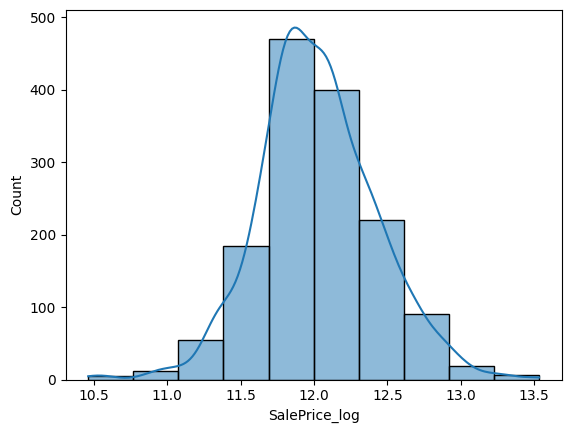

In [25]:
sns.histplot(df["SalePrice_log"], bins=10 , kde=True)

((array([-3.30513952, -3.04793228, -2.90489705, ...,  2.90489705,
          3.04793228,  3.30513952]),
  array([10.46027076, 10.47197813, 10.54273278, ..., 13.34550853,
         13.52114084, 13.53447435])),
 (0.398259646654151, 12.024057394918403, 0.9953761551826701))

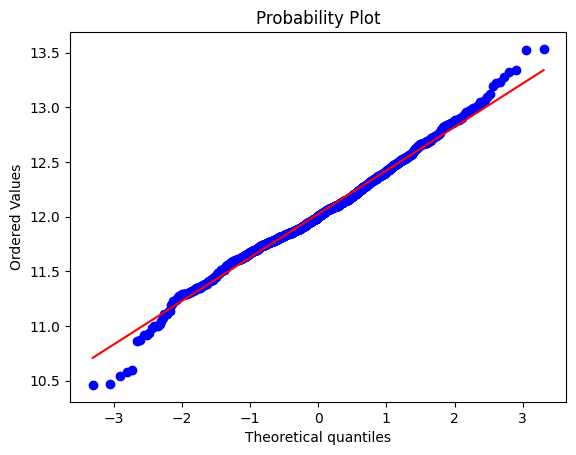

In [27]:
stats.probplot(df["SalePrice_log"], dist="norm", plot=plt)

## Phase 2: The “Cleaning” Ritual (Outlier Handling with IQR)

In [28]:
Q1 = df["SalePrice"].quantile(0.25)
Q3 = df["SalePrice"].quantile(0.75)

In [29]:
IQR = Q3 - Q1

In [32]:
print(f"IQR: {IQR}")

IQR: 84025.0


In [30]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


In [31]:
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

Lower Bound: 3937.5
Upper Bound: 340037.5


<Axes: xlabel='SalePrice'>

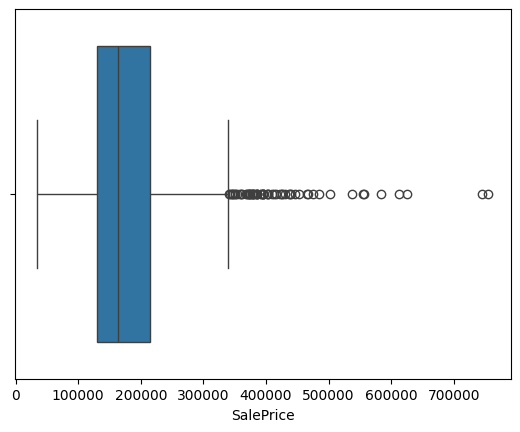

In [33]:
sns.boxplot(x=df["SalePrice"])

In [ ]:
df_new = df[(df["SalePrice"] >= lower_bound) & (df["SalePrice"] <= upper_bound)]

<Axes: xlabel='SalePrice'>

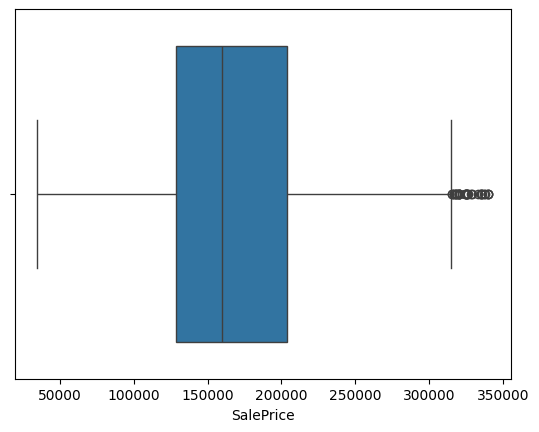

In [37]:
sns.boxplot(x=df_new["SalePrice"])

## Phase 3: Multivariate Analysis & Visualization

In [38]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

In [39]:
corr_matrix = numeric_df.corr()

In [40]:
print(corr_matrix)

                     Id  MSSubClass  LotFrontage   LotArea  OverallQual  \
Id             1.000000    0.011156    -0.010601 -0.033226    -0.028365   
MSSubClass     0.011156    1.000000    -0.386347 -0.139781     0.032628   
LotFrontage   -0.010601   -0.386347     1.000000  0.426095     0.251646   
LotArea       -0.033226   -0.139781     0.426095  1.000000     0.105806   
OverallQual   -0.028365    0.032628     0.251646  0.105806     1.000000   
OverallCond    0.012609   -0.059316    -0.059213 -0.005636    -0.091932   
YearBuilt     -0.012713    0.027850     0.123349  0.014228     0.572323   
YearRemodAdd  -0.021998    0.040581     0.088866  0.013788     0.550684   
MasVnrArea    -0.050298    0.022936     0.193458  0.104160     0.411876   
BsmtFinSF1    -0.005024   -0.069836     0.233633  0.214103     0.239666   
BsmtFinSF2    -0.005968   -0.065649     0.049900  0.111170    -0.059119   
BsmtUnfSF     -0.007940   -0.140759     0.132644 -0.002618     0.308159   
TotalBsmtSF   -0.015415  

<Axes: >

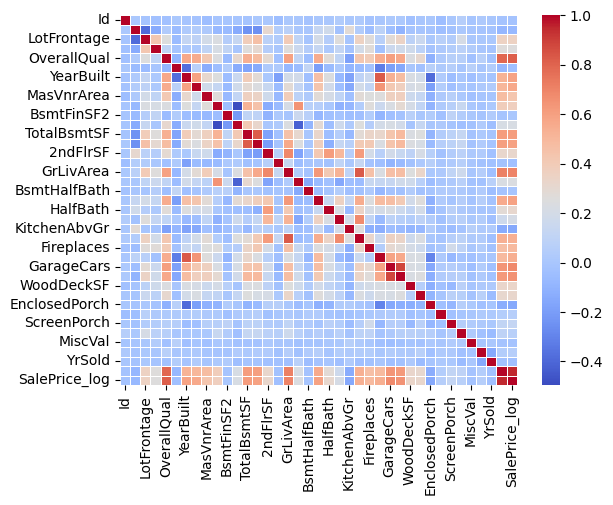

In [41]:
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    linewidths=0.5
)

In [42]:
saleprice_corr = corr_matrix["SalePrice"].sort_values(ascending=False)

In [43]:
top_10_corr = saleprice_corr[1:11]

In [44]:
top_10_corr

SalePrice_log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
Name: SalePrice, dtype: float64

In [46]:
neighborhood_price = (df.groupby("Neighborhood")["SalePrice"].mean().sort_values(ascending=False))

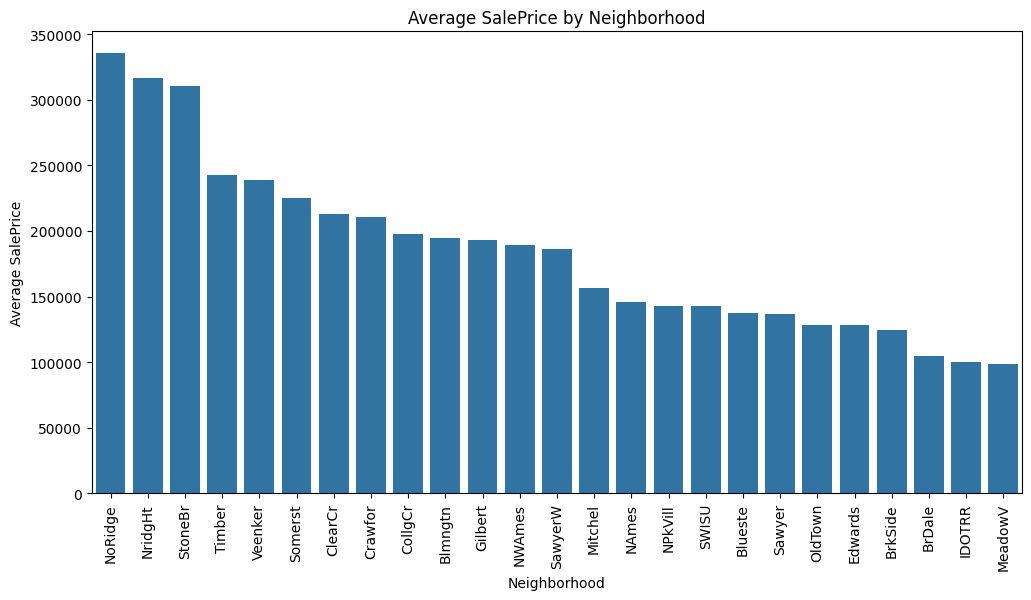

In [49]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=neighborhood_price.index,
    y=neighborhood_price.values
)
plt.xticks(rotation=90)
plt.title("Average SalePrice by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Average SalePrice")
plt.show()


In [48]:
neighborhood_price.head()


Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Name: SalePrice, dtype: float64

## Phase 4: Final Insights & Managerial Report

1.The analysis shows that house prices are primarily driven by three key factors. First, Overall Quality (OverallQual) is the strongest determinant—homes with higher construction and finish quality consistently command higher prices. Second, above-ground living area (GrLivArea) has a strong positive relationship with price, indicating that buyers place high value on usable interior space. Third, garage capacity (GarageCars/GarageArea) meaningfully influences price, reflecting buyer preferences for convenience, storage, and modern living standards. Together, these three variables explain a large share of price variation in the dataset.

2.An anomaly review of missing data reveals that several features have substantial non-random missingness, including PoolQC, MiscFeature, Alley, Fence, and FireplaceQu. In most cases, missing values indicate the absence of the feature rather than data errors (e.g., most homes do not have pools or alley access). If handled incorrectly—such as by outright deletion—this could bias a future predictive model and remove useful signals. The recommended approach is to treat missingness as informative, using category-based imputation (e.g., “None”) or domain-aware strategies rather than simple mean imputation or row removal.

3.The most impactful visual summaries supporting these findings are: (1) the SalePrice distribution and Q-Q plot, which revealed strong right skew and justified a log transformation; (2) boxplots before and after IQR-based outlier removal, demonstrating the reduction of extreme price distortions; (3) the boxplot of OverallQual versus SalePrice, showing a clear monotonic increase in prices with quality; and (4) the bar chart of average SalePrice by Neighborhood, highlighting strong location effects and identifying NoRidge/NridgHt as the “Beverly Hills” of the dataset. These visuals collectively provide clear, decision-ready insights for both modeling and business interpretation.